In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import sys

In [2]:
sys.path.append('../src/')

In [3]:
from visualization import *

# Data import & Pre-processing

Import metadata provided in the CoAuthor Dataset

In [4]:
metadata_argumentative = pd.read_csv('../data/CoAuthor/add_data/metadata_argumentative.csv')
metadata_creative = pd.read_csv('../data/CoAuthor/add_data/metadata_creative.csv')

In [5]:
metadata_argumentative['type'] = 'argumentative'
metadata_creative['type'] = 'creative'

Merge metadata of creative and argumentative sessions

In [6]:
metadata = pd.concat([metadata_argumentative, metadata_creative], ignore_index=True)

In [7]:
metadata.shape

(1445, 14)

Import survey responses provided in the CoAuthor Dataset

In [8]:
survey_argumentative = pd.read_csv('../data/CoAuthor/add_data/survey_argumentative.csv')
survey_creative = pd.read_csv('../data/CoAuthor/add_data/survey_creative.csv')

Get the corresponding session_id and rename the column corresponding to the declared authorship

In [9]:
survey_argumentative = survey_argumentative.rename(columns={
    'Please enter verification code from this writing session (session_id)':'session_id',
    '____% of the essay is written by me (and the rest is written by taking the suggestions). [between 0-100%]':'written_by_human_decla'
})[['session_id', 'written_by_human_decla']]

In [10]:
survey_creative = survey_creative.rename(columns={
    'Please enter verification code from this writing session (session_id)':'session_id',
    '____% of the story is written by me (and the rest is written by taking the suggestions). [between 0-100%]':'written_by_human_decla'
})[['session_id', 'written_by_human_decla']]

In [11]:
survey_argumentative.drop_duplicates(subset=['session_id'], keep='first', inplace=True)
survey_creative.drop_duplicates(subset=['session_id'], keep='first', inplace=True)

In [12]:
print(survey_argumentative.shape)
print(survey_creative.shape)

(623, 2)
(832, 2)


Merge survey responses of creative and argumentative sessions

In [13]:
survey_combined = pd.concat([
    survey_argumentative[['session_id', 'written_by_human_decla']],
    survey_creative[['session_id', 'written_by_human_decla']]
], ignore_index=True)

In [14]:
survey_combined

,session_id,written_by_human_decla
0,397a3daa2e234b5aac44e3756e7399b7,80
1,99dcceb9d7394bd1986fbf3572b3efcd,50
2,3778eebfc9df42429aa1f23db1934a9d,95
3,2479e0314b8d41fcbfb626f38d2029d8,80
4,7d2b65dc5d284f18a56270271f023352,30
...,...,...
1450,2b373ca5921e4e2c8114e20114f04de8,90
1451,80e39947253d4491a8b294de724100f0,78
1452,2194c0e020934c74b8ab6c28d758feb2,79
1453,78d615e3799e47078bf75a1799f4620a,87


Import computed metrics (especially the number of GPT calls) (Script of Shibani *et al.*, 2019)

In [15]:
metrics = pd.read_csv('../data/metrics.csv')

In [16]:
metrics['file_name'] = metrics['file_name'].str.split('.').str[0]
metrics.rename(columns={'file_name': 'session_id'}, inplace=True)

Merge metadata and survey responses and metrics in a unique dataframe

In [17]:
all_metrics= metadata.merge(survey_combined, on='session_id', how='left')

In [18]:
all_metrics = all_metrics.merge(metrics[['session_id', 'nb_gpt_calls']], on='session_id', how='left')

In [19]:
all_metrics.shape

(1445, 16)

Replace values in wrongly formated in the 'written_by_human_decla' column

In [20]:
all_metrics['written_by_human_decla'] = all_metrics['written_by_human_decla'].replace(
    {'90-10%': 95, '99.9': 99, '97%': 97, '90%': 90}
)

Look at the missing values

In [21]:
all_metrics['written_by_human'].isna().sum()

np.int64(0)

In [22]:
all_metrics['written_by_human_decla'].isna().sum()

np.int64(193)

Remove data for which the declared authorship is missing

In [23]:
all_metrics = all_metrics.dropna(subset=['written_by_human_decla'])

In [24]:
all_metrics['written_by_human'] = all_metrics['written_by_human'].astype(int)
all_metrics['written_by_human_decla'] = all_metrics['written_by_human_decla'].astype(int)

In [25]:
all_metrics['type'].value_counts()

type
creative         744
argumentative    508
Name: count, dtype: int64

# Compute Authorship Calibration

In [26]:
all_metrics['calibration'] = all_metrics['written_by_human_decla'].astype(int) - all_metrics['written_by_human'].astype(int)


In [27]:
all_metrics['calibration_score'] = all_metrics['calibration'] / 100

# Analysis: Overall Authorship Calibration Scores

In [28]:
all_metrics['calibration_score'].describe()

count    1252.000000
mean       -0.003035
std         0.138009
min        -0.530000
25%        -0.080000
50%         0.000000
75%         0.070000
max         0.490000
Name: calibration_score, dtype: float64

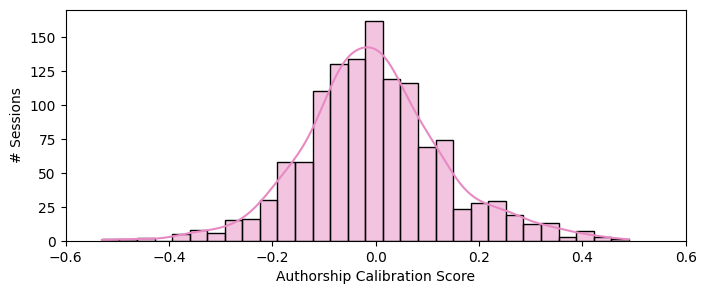

In [29]:
plot_scores_distribution(all_metrics['calibration_score'], color=plt.cm.Set2(3), name_fig='global', save_fig=True)

# Users Categorization Based on the Frequency of AI Use
Split users into High-GPT usage and Low-GPT usage groups based on the mean number of GPT calls. If the number is above or equal to the median, assign to the High-GPT usage group, otherwise assign to the Low-GPT usage group.

In [30]:
all_metrics['nb_gpt_calls'].describe()

count    1251.000000
mean       12.982414
std         9.593398
min         0.000000
25%         6.000000
50%        11.000000
75%        17.000000
max        65.000000
Name: nb_gpt_calls, dtype: float64

In [31]:
all_metrics['group'] = all_metrics['nb_gpt_calls'].apply(lambda x: 'High' if x >= all_metrics['nb_gpt_calls'].median() else 'Low')

In [32]:
all_metrics['group'].value_counts()

group
High    647
Low     605
Name: count, dtype: int64

# Analysis: Authorship Calibration Across Low- and High-AI Usage Groups

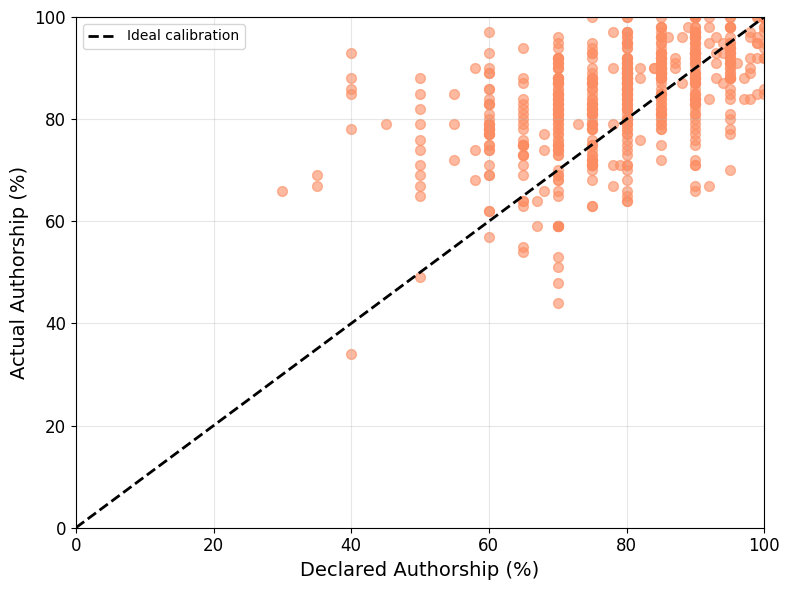

In [33]:
plot_calibration_curves(all_metrics[all_metrics['group']=='Low'], color=plt.cm.Set2(1), name_fig='low', save_fig=True)

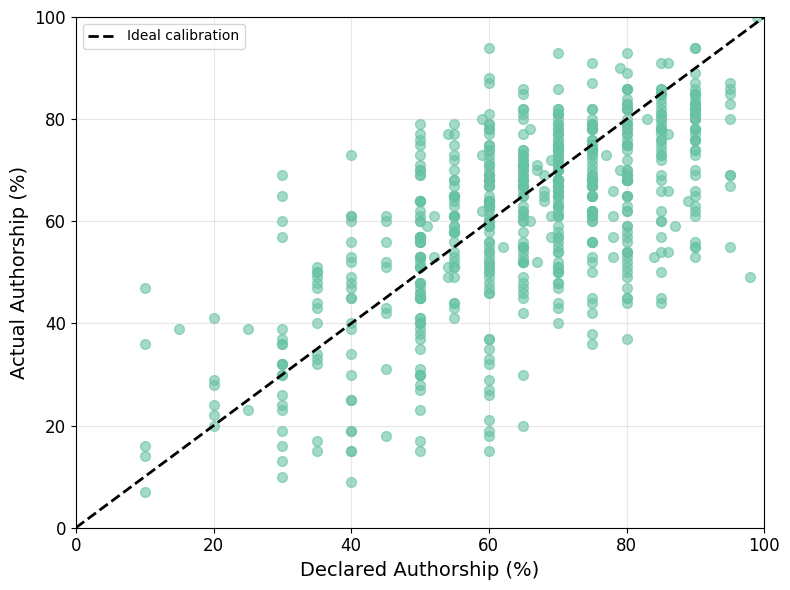

In [34]:
plot_calibration_curves(all_metrics[all_metrics['group']=='High'], color=plt.cm.Set2(0), name_fig='low', save_fig=True)

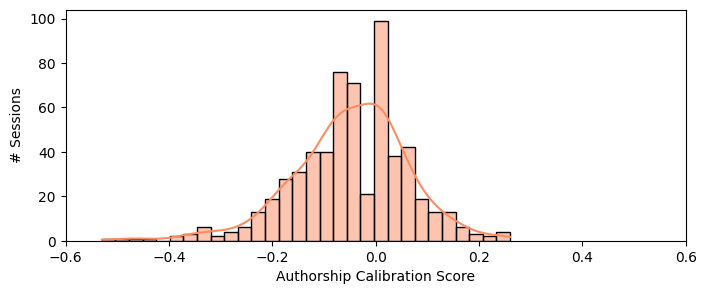

In [35]:
plot_scores_distribution(all_metrics[all_metrics['group']=='Low']['calibration_score'], color=plt.cm.Set2(1), name_fig='low', save_fig=True)

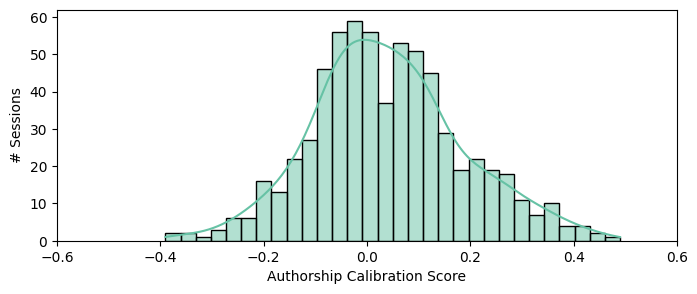

In [36]:
plot_scores_distribution(all_metrics[all_metrics['group']=='High']['calibration_score'], color=plt.cm.Set2(0), name_fig='low', save_fig=True)

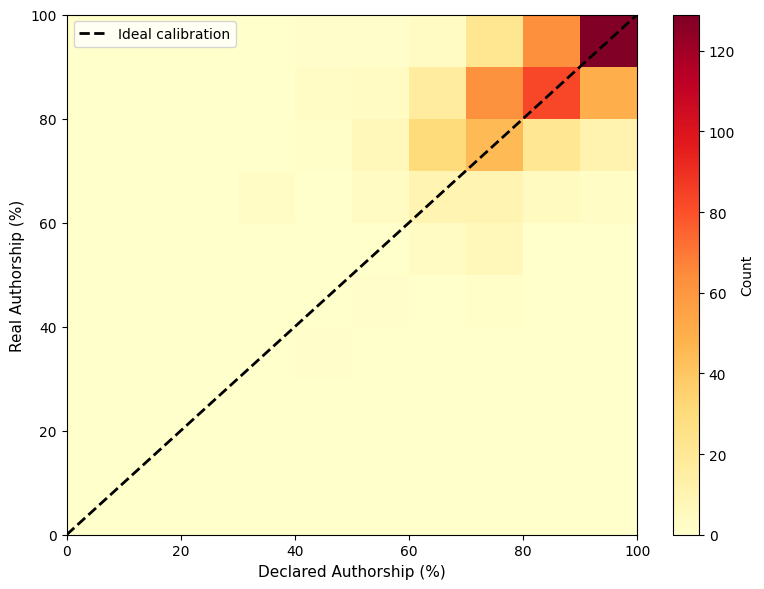

In [37]:
plot_heatmap(all_metrics[all_metrics['group']=='Low'], name_fig='low', save_fig=True)

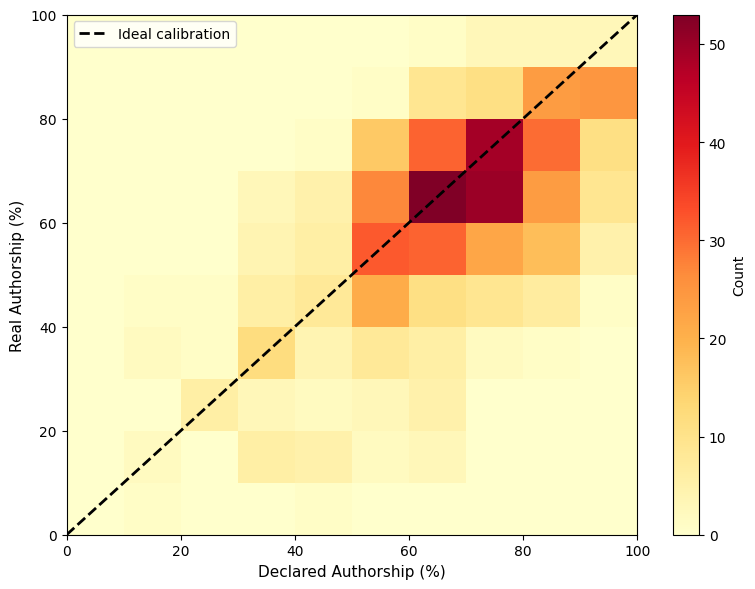

In [38]:
plot_heatmap(all_metrics[all_metrics['group']=='High'], name_fig='low', save_fig=True)

# Statistical test

In [39]:
x = all_metrics[all_metrics['group'] == 'High']['calibration_score']
y = all_metrics[all_metrics['group'] == 'Low']['calibration_score']

In [40]:
stat, p = mannwhitneyu(x, y)

print(f'Mann-Whitney U test statistic: {stat}, p-value: {p}')

Mann-Whitney U test statistic: 265997.0, p-value: 3.9371354245482665e-28
